Proiect ML – Predicția categoriei produsului din titlu

Obiectiv: Construiesc un model de clasificare care prezice categoria unui produs folosind doar Product Title, pentru a automatiza clasificarea în platforma de e-commerce.

Pași:

1. Încarc datasetul products.csv

2. Curăț și standardizez datele (inclusiv numele de coloane)

3. Feature engineering (caracteristici simple din titlu)

4. Construiesc pipeline (TF-IDF + features numerice)

5. Compar 2 modele: Logistic Regression și Linear SVM

6. Evaluez: Accuracy, Macro F1, classification report + confusion matrix (top categorii)

7. Aleg modelul final și îl salvez ca model.pkl

8. Generez scripturile cerute: train_model.py și predict_category.py

In [1]:
!pip -q install pandas numpy scikit-learn joblib matplotlib


In [2]:
from google.colab import files
uploaded = files.upload()  # selectezi products.csv de pe calculator


Saving products.csv to products.csv


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

df = pd.read_csv("products.csv")

# IMPORTANT: în datasetul meu există spații în numele unor coloane
# (ex: " Category Label", " Listing Date  "), deci le normalizez:
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (35311, 8)
Columns: ['product ID', 'Product Title', 'Merchant ID', 'Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


Selectarea coloanelor necesare (title + label)

Pentru modelul cerut în temă, folosesc doar:

- Product Title ca input

- Category Label ca target

Deși datasetul are și views, rating etc., în practică un produs nou poate să nu aibă încă vizualizări, deci mă bazez pe titlu (scenariul real de business din enunț).

In [5]:
df = df.rename(columns={
    "Product Title": "title",
    "Category Label": "label"
}).copy()

df[["title", "label"]].head()


,title,label
0,apple iphone 8 plus 64gb silver,Mobile Phones
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,Mobile Phones
3,apple iphone 8 plus 64gb space grey,Mobile Phones
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones


Curățarea datelor (Data Cleaning)

Fac următoarele:

- normalizez textul titlului (lowercase + spații multiple)

- elimin rânduri cu titlu/categorie lipsă

- elimin duplicate (title + label)

In [6]:
import re

def clean_title(text):
    if pd.isna(text):
        return ""
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)  # spații multiple -> un singur spațiu
    return text

before = df.shape[0]

df["title"] = df["title"].apply(clean_title)
df["label"] = df["label"].astype(str).str.strip()

# elimin rânduri invalide
df = df[(df["title"] != "") & (df["label"] != "")]
# elimin duplicate
df = df.drop_duplicates(subset=["title", "label"]).reset_index(drop=True)

after = df.shape[0]

print("Rows before:", before)
print("Rows after :", after)
print("Unique labels:", df["label"].nunique())
df.head()


Rows before: 35311
Rows after : 30929
Unique labels: 14


,product ID,title,Merchant ID,label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


Explorare rapidă (EDA)

Verific distribuția categoriilor (top 15) ca să observ dacă datasetul este dezechilibrat.

label
Fridge Freezers     4809
Mobile Phones       3614
Washing Machines    3403
TVs                 3275
Fridges             3093
Dishwashers         3042
CPUs                2986
Digital Cameras     2405
Microwaves          2094
Freezers            1903
fridge               123
CPU                   84
Mobile Phone          55
nan                   43
Name: count, dtype: int64


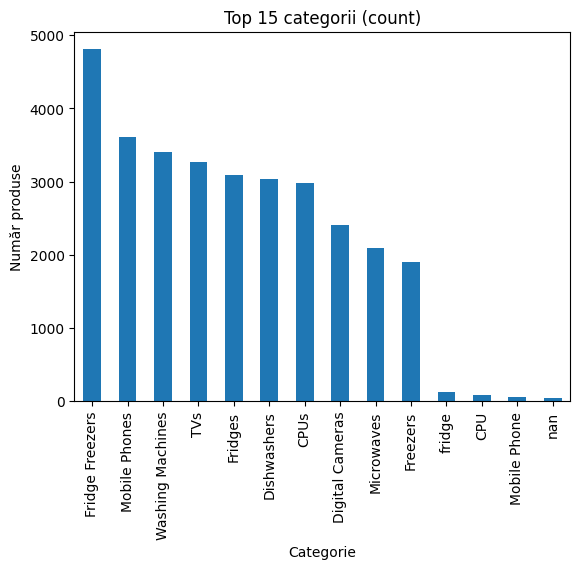

In [7]:
import matplotlib.pyplot as plt

top = df["label"].value_counts().head(15)
print(top)

top.plot(kind="bar")
plt.title("Top 15 categorii (count)")
plt.xlabel("Categorie")
plt.ylabel("Număr produse")
plt.show()


Feature Engineering din titlu

Pe lângă TF-IDF, adaug features simple:

- lungime titlu (caractere)

- număr cuvinte

- dacă are cifre

- număr caractere speciale

- lungimea celui mai lung cuvânt

Acestea ajută la diferențiere (GB, kg, modele, coduri etc.)

In [8]:
import numpy as np

titles = df["title"].fillna("").astype(str)

df["title_len_chars"] = titles.str.len().astype(int)
df["title_len_words"] = titles.apply(lambda x: len(str(x).split())).astype(int)
df["has_digits"] = titles.str.contains(r"\d", regex=True).astype(int)
df["special_char_count"] = titles.apply(lambda x: len(re.findall(r"[^a-zA-Z0-9\s]", str(x)))).astype(int)
df["max_word_len"] = titles.apply(lambda x: max([len(w) for w in str(x).split()] + [0])).astype(int)

df[["title","title_len_chars","title_len_words","has_digits","special_char_count","max_word_len"]].head()


,title,title_len_chars,title_len_words,has_digits,special_char_count,max_word_len
0,apple iphone 8 plus 64gb silver,31,6,1,0,6
1,apple iphone 8 plus 64 gb spacegrau,35,7,1,0,9
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,70,13,1,2,10
3,apple iphone 8 plus 64gb space grey,35,7,1,0,6
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,54,11,1,1,8


Pregătirea seturilor train/test

Folosesc stratify=y ca să păstrez proporțiile pe categorii.

In [9]:
from sklearn.model_selection import train_test_split

feature_cols = ["title", "title_len_chars", "title_len_words", "has_digits", "special_char_count", "max_word_len"]

X = df[feature_cols].copy()
y = df["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (24743, 6)  Test: (6186, 6)


Pipeline: TF-IDF + features numerice + 2 modele

Modele comparate:

1. Logistic Regression (bun baseline pentru text)

2. Linear SVM (LinearSVC) (de multe ori foarte bun pe clasificare text)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9), "title"),
        ("num", "passthrough", ["title_len_chars","title_len_words","has_digits","special_char_count","max_word_len"]),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

models = {
    "LogisticRegression": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "LinearSVC": Pipeline([
        ("prep", preprocessor),
        ("clf", LinearSVC())
    ])
}

models


{'LogisticRegression': Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('tfidf',
                                                   TfidfVectorizer(max_df=0.9,
                                                                   min_df=2,
                                                                   ngram_range=(1,
                                                                                2)),
                                                   'title'),
                                                  ('num', 'passthrough',
                                                   ['title_len_chars',
                                                    'title_len_words',
                                                    'has_digits',
                                                    'special_char_count',
                                                    'max_word_len'])])),
                 ('clf',
                  LogisticRegression(class_weight='bal

Evaluare modele (Accuracy, Macro F1, Report)

Folosesc:

- Accuracy

- Macro F1 (important când sunt multe clase și datasetul poate fi dezechilibrat)

- Classification report

In [11]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

results = []
best_name, best_f1, best_model = None, -1.0, None

for name, model in models.items():
    print("\n==============================")
    print("Model:", name)
    print("==============================")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1m = f1_score(y_test, preds, average="macro")

    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(f1m, 4))
    print("\nClassification report (summary):")
    print(classification_report(y_test, preds, zero_division=0))

    results.append((name, acc, f1m))

    if f1m > best_f1:
        best_name, best_f1, best_model = name, f1m, model

print("\n===== Rezultate sortate după Macro F1 =====")
for n, a, f in sorted(results, key=lambda x: x[2], reverse=True):
    print(f"{n:18s}  acc={a:.4f}  macro_f1={f:.4f}")

print("\nModel ales:", best_name, " Macro F1:", round(best_f1, 4))



Model: LogisticRegression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9135
Macro F1: 0.6751

Classification report (summary):
                  precision    recall  f1-score   support

             CPU       0.02      0.06      0.03        17
            CPUs       0.96      0.92      0.94       597
 Digital Cameras       0.99      0.98      0.99       481
     Dishwashers       0.88      0.94      0.91       608
        Freezers       0.90      0.93      0.91       381
 Fridge Freezers       0.97      0.87      0.92       962
         Fridges       0.85      0.79      0.82       619
      Microwaves       0.96      0.95      0.95       419
    Mobile Phone       0.00      0.00      0.00        11
   Mobile Phones       0.95      0.95      0.95       723
             TVs       0.97      0.98      0.98       655
Washing Machines       0.93      0.94      0.94       681
          fridge       0.05      0.12      0.07        24
             nan       0.03      0.12      0.05         8

        accuracy                           0.91      6186
  

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.9483
Macro F1: 0.6825

Classification report (summary):
                  precision    recall  f1-score   support

             CPU       0.00      0.00      0.00        17
            CPUs       0.97      1.00      0.98       597
 Digital Cameras       1.00      0.99      1.00       481
     Dishwashers       0.96      0.92      0.94       608
        Freezers       0.99      0.91      0.95       381
 Fridge Freezers       0.93      0.93      0.93       962
         Fridges       0.89      0.90      0.90       619
      Microwaves       0.99      0.96      0.97       419
    Mobile Phone       0.00      0.00      0.00        11
   Mobile Phones       0.97      1.00      0.98       723
             TVs       0.98      0.99      0.99       655
Washing Machines       0.88      0.97      0.92       681
          fridge       0.00      0.00      0.00        24
             nan       0.00      0.00      0.00         8

        accuracy                           0.95      6186
  

Confusion Matrix (vizualizare utilă)

La multe categorii, matricea completă este uriașă.
Pentru vizualizare clară, afișez confusion matrix doar pentru top 20 cele mai frecvente categorii.

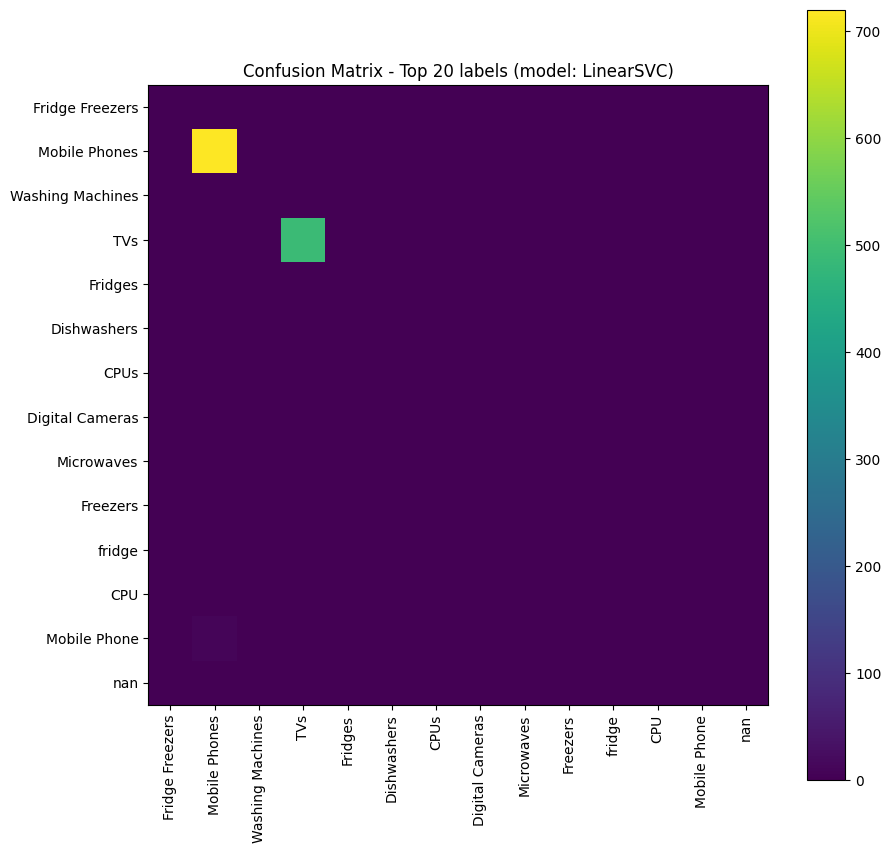

Confusion matrix shape (top 20): (14, 14)


In [12]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

preds_best = best_model.predict(X_test)

top_labels = df["label"].value_counts().head(20).index.tolist()

mask_true = y_test.isin(top_labels)
mask_pred = pd.Series(preds_best).isin(top_labels)

mask = mask_true & mask_pred

y_true_top = y_test[mask]
y_pred_top = pd.Series(preds_best, index=y_test.index)[mask]

cm = confusion_matrix(y_true_top, y_pred_top, labels=top_labels)

plt.figure(figsize=(10,10))
plt.imshow(cm)
plt.title(f"Confusion Matrix - Top 20 labels (model: {best_name})")
plt.xticks(range(len(top_labels)), top_labels, rotation=90)
plt.yticks(range(len(top_labels)), top_labels)
plt.colorbar()
plt.show()

print("Confusion matrix shape (top 20):", cm.shape)


Model final: reantrenare pe tot datasetul + salvare

După alegerea modelului cu Macro F1 cel mai bun, îl antrenez pe tot setul și îl salvez în model.pkl.

In [13]:
import joblib

best_model.fit(X, y)

MODEL_PATH = "model.pkl"
joblib.dump(best_model, MODEL_PATH)

print("Model salvat în:", MODEL_PATH)


Model salvat în: model.pkl


In [14]:
test_titles = [
    "iphone 7 32gb gold,4,3,Apple iPhone 7 32GB",
    "olympus e m10 mark iii geh use silber",
    "kenwood k20mss15 solo",
    "bosch wap28390gb 8kg 1400 spin",
    "bosch serie 4 kgv39vl31g",
    "smeg sbs8004po"
]

def make_features_single(title):
    t = clean_title(title)
    s = pd.Series([t])
    out = pd.DataFrame({"title": s})
    out["title_len_chars"] = s.str.len().astype(int)
    out["title_len_words"] = s.apply(lambda x: len(str(x).split())).astype(int)
    out["has_digits"] = s.str.contains(r"\d", regex=True).astype(int)
    out["special_char_count"] = s.apply(lambda x: len(re.findall(r"[^a-zA-Z0-9\s]", str(x)))).astype(int)
    out["max_word_len"] = s.apply(lambda x: max([len(w) for w in str(x).split()] + [0])).astype(int)
    return out

for t in test_titles:
    pred = best_model.predict(make_features_single(t))[0]
    print(f"{t}  -->  {pred}")


iphone 7 32gb gold,4,3,Apple iPhone 7 32GB  -->  Mobile Phones
olympus e m10 mark iii geh use silber  -->  Digital Cameras
kenwood k20mss15 solo  -->  Microwaves
bosch wap28390gb 8kg 1400 spin  -->  Washing Machines
bosch serie 4 kgv39vl31g  -->  Fridge Freezers
smeg sbs8004po  -->  Dishwashers


Generarea scripturilor train_model.py și predict_category.py

Ca să le pot pune ușor în repo, le scriu direct din notebook cu %%writefile.

In [15]:
%%writefile train_model.py
import os
import re
import argparse
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


def clean_title(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


def add_title_features(df: pd.DataFrame) -> pd.DataFrame:
    titles = df["title"].fillna("").astype(str)

    df["title_len_chars"] = titles.str.len().astype(int)
    df["title_len_words"] = titles.apply(lambda x: len(str(x).split())).astype(int)
    df["has_digits"] = titles.str.contains(r"\d", regex=True).astype(int)
    df["special_char_count"] = titles.apply(lambda x: len(re.findall(r"[^a-zA-Z0-9\s]", str(x)))).astype(int)
    df["max_word_len"] = titles.apply(lambda x: max([len(w) for w in str(x).split()] + [0])).astype(int)
    return df


def load_data(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Nu găsesc fișierul: {csv_path}")

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()  # FIX: datasetul are spații în numele coloanelor

    df = df.rename(columns={
        "Product Title": "title",
        "Category Label": "label"
    }).copy()

    df["title"] = df["title"].apply(clean_title)
    df["label"] = df["label"].astype(str).str.strip()

    df = df[(df["title"] != "") & (df["label"] != "")]
    df = df.drop_duplicates(subset=["title", "label"]).reset_index(drop=True)

    df = add_title_features(df)
    return df


def build_models():
    preprocessor = ColumnTransformer(
        transformers=[
            ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9), "title"),
            ("num", "passthrough", ["title_len_chars","title_len_words","has_digits","special_char_count","max_word_len"]),
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

    models = {
        "LogisticRegression": Pipeline([
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ]),
        "LinearSVC": Pipeline([
            ("prep", preprocessor),
            ("clf", LinearSVC())
        ])
    }
    return models


def main():
    parser = argparse.ArgumentParser(description="Train product category classifier from titles.")
    parser.add_argument("--data", type=str, default="products.csv", help="Path to products.csv")
    parser.add_argument("--out", type=str, default="model.pkl", help="Output path for model.pkl")
    args = parser.parse_args()

    df = load_data(args.data)

    feature_cols = ["title","title_len_chars","title_len_words","has_digits","special_char_count","max_word_len"]
    X = df[feature_cols].copy()
    y = df["label"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = build_models()

    best_name, best_f1, best_model = None, -1.0, None
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1m = f1_score(y_test, preds, average="macro")

        print("\n==============================")
        print("Model:", name)
        print("Accuracy:", round(acc, 4))
        print("Macro F1:", round(f1m, 4))
        print(classification_report(y_test, preds, zero_division=0))

        if f1m > best_f1:
            best_name, best_f1, best_model = name, f1m, model

    print("\nBest model:", best_name, "Macro F1:", round(best_f1, 4))

    # Refit on all data
    best_model.fit(X, y)
    joblib.dump(best_model, args.out)
    print("Saved model to:", args.out)


if __name__ == "__main__":
    main()


Writing train_model.py


In [16]:
%%writefile predict_category.py
import argparse
import joblib
import pandas as pd
import re


def clean_title(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


def make_features(title: str) -> pd.DataFrame:
    t = clean_title(title)
    s = pd.Series([t])

    df = pd.DataFrame({"title": s})
    df["title_len_chars"] = s.str.len().astype(int)
    df["title_len_words"] = s.apply(lambda x: len(str(x).split())).astype(int)
    df["has_digits"] = s.str.contains(r"\d", regex=True).astype(int)
    df["special_char_count"] = s.apply(lambda x: len(re.findall(r"[^a-zA-Z0-9\s]", str(x)))).astype(int)
    df["max_word_len"] = s.apply(lambda x: max([len(w) for w in str(x).split()] + [0])).astype(int)
    return df


def main():
    parser = argparse.ArgumentParser(description="Interactive category predictor")
    parser.add_argument("--model", type=str, default="model.pkl")
    args = parser.parse_args()

    model = joblib.load(args.model)

    print("Model loaded. Introdu titlul produsului (exit pentru ieșire).")
    while True:
        title = input("Titlu produs: ").strip()
        if title.lower() in {"exit", "quit", "q"}:
            print("Bye!")
            break

        X = make_features(title)
        pred = model.predict(X)[0]
        print("Categoria prezisă:", pred)


if __name__ == "__main__":
    main()


Writing predict_category.py


In [17]:
!ls -la


total 7832
drwxr-xr-x 1 root root    4096 Jan  9 21:40 .
drwxr-xr-x 1 root root    4096 Jan  9 21:30 ..
drwxr-xr-x 4 root root    4096 Dec 11 14:34 .config
drwx------ 5 root root    4096 Jan  9 21:33 drive
-rw-r--r-- 1 root root 4208853 Jan  9 21:40 model.pkl
-rw-r--r-- 1 root root    1401 Jan  9 21:40 predict_category.py
-rw-r--r-- 1 root root 3778705 Jan  9 21:32 products.csv
drwxr-xr-x 1 root root    4096 Dec 11 14:34 sample_data
-rw-r--r-- 1 root root    4039 Jan  9 21:40 train_model.py


In [18]:
from google.colab import files
files.download("train_model.py")
files.download("predict_category.py")
files.download("model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>